# Capstone Project

Bu proje, Kaggle üzerinde bulunan GTSRB - German Traffic Sign Recognition Benchmark veri setini kullanarak, otonom araç teknolojilerinin temel taşlarından biri olan trafik işareti sınıflandırmasını gerçekleştirmeyi amaçlar.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

In [2]:
# Veri seti yolu (Kaggle'dan indirdiğiniz klasörün yolu)
data_dir = './gtsrb' 
train_path = os.path.join(data_dir, 'Train')
test_path = os.path.join(data_dir, 'Test')

In [3]:
# Sınıf sayısı (Trafik işareti türü)
NUM_CLASSES = 43
IMG_HEIGHT = 30
IMG_WIDTH = 30
CHANNELS = 3

In [14]:
# Trafik İşaretlerinin İsimleri (Sınıf ID -> İsim)
classes = { 
    0:'Hiz Limiti (20km/s)',
    1:'Hiz Limiti (30km/s)', 
    2:'Hiz Limiti (50km/s)', 
    3:'Hiz Limiti (60km/s)', 
    4:'Hiz Limiti (70km/s)', 
    5:'Hiz Limiti (80km/s)', 
    6:'Hiz Limiti Sonu (80km/s)', 
    7:'Hiz Limiti (100km/s)', 
    8:'Hiz Limiti (120km/s)', 
    9:'Gecis Yok', 
    10:'3.5 Ton Uzeri Araclar Giremez', 
    11:'Kavsakta Gecis Hakkı', 
    12:'Anayol', 
    13:'Yol Ver', 
    14:'Dur', 
    15:'Tasıt Giremez', 
    16:'3.5 Ton Uzeri Araclar Yasak', 
    17:'Girisi Olmayan Yol', 
    18:'Genel Tehlike', 
    19:'Sola Tehlikeli Viraj', 
    20:'Saga Tehlikeli Viraj', 
    21:'Cift Yönlü Viraj', 
    22:'Engebeli Yol', 
    23:'Kaygan Yol', 
    24:'Yol Daraliyor (Sagdan)', 
    25:'Yol Calismasi', 
    26:'Trafik ISiklari', 
    27:'Yaya Geçidi', 
    28:'Okul Geçidi', 
    29:'Bisiklet Geçidi', 
    30:'Buzlanma/Kar Tehlikesi', 
    31:'Vahsi Hayvan Cikabilir', 
    32:'Hiz Siniri Sonu', 
    33:'Saga Mecbur Yon', 
    34:'Sola Mecbur Yon', 
    35:'Ileri ve Saga Mecbur Yon', 
    36:'Ileri ve Sola Mecbur Yon', 
    37:'Mecbur Ileri Yon', 
    38:'Sagdan/Soldan Gidiniz', 
    39:'Soldan Gidiniz', 
    40:'Doner Kavsak', 
    41:'Gecis Yasagi Sonu', 
    42:'3.5 Ton Uzeri Araclar Için Gecis Yasagi Sonu' 
}

In [5]:
# Verilerin Yüklenmesi ve İşlenmesi
image_data = []
image_labels = []

print("Veriler yükleniyor, lütfen bekleyiniz...")

try:
    for i in range(NUM_CLASSES):
        path = os.path.join(train_path, str(i))
        images = os.listdir(path)
        
        for img in images:
            try:
                image = cv2.imread(os.path.join(path, img))
                image_fromarray = Image.fromarray(image, 'RGB')
                resize_image = image_fromarray.resize((IMG_HEIGHT, IMG_WIDTH))
                image_data.append(np.array(resize_image))
                image_labels.append(i)
            except:
                print("Hata: Resim yüklenemedi " + img)
                
    # Listeleri numpy array'e çevirme
    image_data = np.array(image_data)
    image_labels = np.array(image_labels)
    
    print(f"Yüklenen toplam görüntü sayısı: {image_data.shape[0]}")
    
except Exception as e:
    print(f"Bir hata oluştu: {e}")
    print("Lütfen veri seti yolunun doğru olduğundan emin olun.")

# Veriyi karıştırma (Shuffle)
shuffle_indexes = np.arange(image_data.shape[0])
np.random.shuffle(shuffle_indexes)
image_data = image_data[shuffle_indexes]
image_labels = image_labels[shuffle_indexes]

# Eğitim ve Doğrulama setine ayırma (%80 Eğitim, %20 Doğrulama)
X_train, X_val, y_train, y_val = train_test_split(image_data, image_labels, test_size=0.2, random_state=42)

# Normalizasyon (Piksel değerlerini 0-1 arasına çekme)
X_train = X_train / 255.0
X_val = X_val / 255.0

# Etiketleri One-Hot Encoding yapma
y_train = to_categorical(y_train, NUM_CLASSES)
y_val = to_categorical(y_val, NUM_CLASSES)

print("Veri hazırlığı tamamlandı.")

Veriler yükleniyor, lütfen bekleyiniz...
Yüklenen toplam görüntü sayısı: 39209
Veri hazırlığı tamamlandı.


In [6]:
# CNN Modelinin Oluşturulması
model = Sequential()

# İlk Konvolüsyon Katmanı
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(IMG_HEIGHT,IMG_WIDTH,CHANNELS)))
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

# İkinci Konvolüsyon Katmanı
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

# Tam Bağlantılı Katman (Dense)
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(NUM_CLASSES, activation='softmax')) # Çıkış katmanı

# Modeli Derleme
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

C:\Users\kosey\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 9, 9, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 612,427 (2.34 MB)

 Trainable params: 612,427 (2.34 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Modelin Eğitilmesi
history = model.fit(X_train, y_train, batch_size=32, epochs=15, validation_data=(X_val, y_val))

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.7266 - loss: 0.9625 - val_accuracy: 0.9713 - val_loss: 0.0984
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9598 - loss: 0.1374 - val_accuracy: 0.9915 - val_loss: 0.0335
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9736 - loss: 0.0893 - val_accuracy: 0.9941 - val_loss: 0.0240
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9801 - loss: 0.0664 - val_accuracy: 0.9952 - val_loss: 0.0206
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.9827 - loss: 0.0571 - val_accuracy: 0.9958 - val_loss: 0.0174
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.9843 - loss: 0.0524 - val_accuracy: 0.9958 - val_loss: 0.0175
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9872 - loss: 0.0410 - val_accuracy: 0.9973 - val_loss: 0.0134
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9880 - loss: 0.0389 - 

In [8]:
# 0.9921 Accuracy elde edildi. Modelin Kaydediyoruz.
model.save('traffic_classifier.h5')

In [9]:
model.save('traffic_classifier.keras')

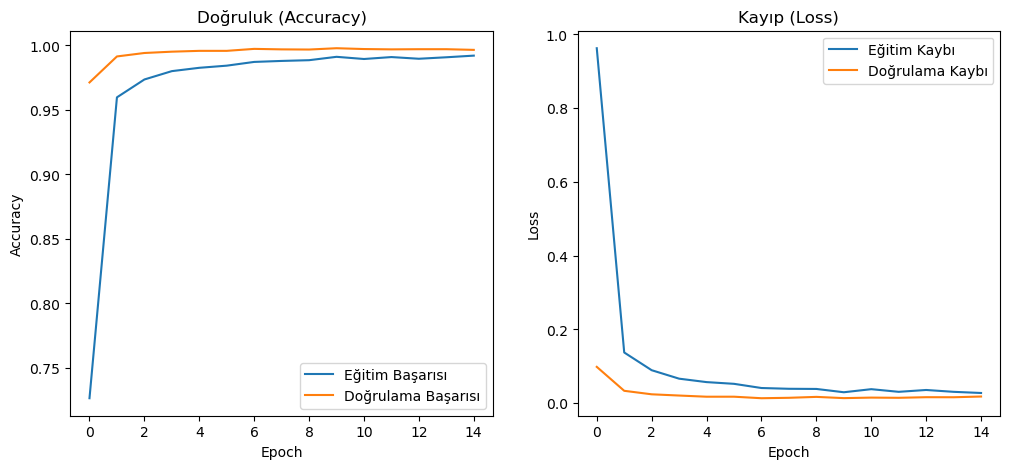

In [10]:
# Eğitim Sonuçlarının Görselleştirilmesi
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
plt.plot(history.history['val_accuracy'], label='Doğrulama Başarısı')
plt.title('Doğruluk (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Kayıp (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [18]:
# GERÇEK ZAMANLI TAHMİN (IP WEBCAM veya WEBCAM)

import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Eğitilmiş modeli yükle
model = load_model('traffic_classifier.h5')

# IP Webcam URL'si (Kendi telefonunuzdaki IP ile güncelleyin)
# Eğer IP kamera çalışmazsa, 0 yazarak bilgisayar kamerasını kullanabilirsiniz.
url = 'http://192.168.0.101:8080/video'
cap = cv2.VideoCapture(url)

font = cv2.FONT_HERSHEY_SIMPLEX
threshold = 0.75 # Tahmin emin olma eşiği (%75)

print("Çıkmak için 'q' tuşuna basınız.")

while True:
    ret, frame = cap.read()
    
    if not ret:
        print("Görüntü alınamıyor.")
        break

    # Görüntüyü modelin anlayacağı formata getirme
    # 1. Resmi modele uygun boyuta getir (30x30)
    img = Image.fromarray(frame, 'RGB')
    img = img.resize((IMG_HEIGHT, IMG_WIDTH))
    img = np.array(img)
    
    # 2. Boyut genişletme (batch boyutu ekleme: 1, 30, 30, 3)
    img = np.expand_dims(img, axis=0)
    
    # 3. Normalizasyon (Eğitimdeki gibi)
    img = img / 255.0
    
    # Tahmin yapma
    predictions = model.predict(img)
    class_index = np.argmax(predictions)
    probability = np.max(predictions)
    
    # Ekrana yazdırma
    if probability > threshold:
        sign_name = classes[class_index]
        cv2.putText(frame, f"Isaret: {sign_name}", (10, 35), font, 0.75, (0, 255, 0), 2, cv2.LINE_AA)
        cv2.putText(frame, f"Olasilik: {round(probability*100, 2)}%", (10, 75), font, 0.75, (0, 255, 0), 2, cv2.LINE_AA)
        
        # Ekranda algılanan bölgeyi göstermek için (
        Tüm ekranı analiz ediyoruz ama efekt olarak)
        cv2.rectangle(frame, (0, 0), (200, 90), (0,0,0), -1) # Arka plan siyah kutu (yazı okunabilsin diye)
        # Yazıları tekrar üstüne yazıyoruz çünkü rectangle üstünü kapattı
        cv2.putText(frame, f"Isaret: {sign_name}", (10, 35), font, 0.6, (255, 255, 255), 1, cv2.LINE_AA)
        cv2.putText(frame, f"Olasilik: {round(probability*100, 2)}%", (10, 70), font, 0.6, (255, 255, 255), 1, cv2.LINE_AA)
    else:
        cv2.putText(frame, "Trafik Isareti Araniyor...", (10, 35), font, 0.75, (0, 0, 255), 2, cv2.LINE_AA)

    cv2.imshow("Trafik Isareti Tanima - Canli", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

SyntaxError: unmatched ')' (3481270742.py, line 51)